In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("E-Commerce Sales Analytics.csv")

In [4]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [6]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [7]:
df[['product_category', 'region']].value_counts().reset_index(name='count')

,product_category,region,count
0,Electronics,North,462
1,Electronics,South,455
2,Electronics,West,442
3,Electronics,East,418
4,Clothing,East,395
5,Clothing,West,393
6,Clothing,North,378
7,Clothing,South,365
8,Home,West,262
9,Home,East,249


In [8]:
df['payment_method'].value_counts()

payment_method
Card      2270
COD       1774
Wallet     956
Name: count, dtype: int64

In [9]:
# Contoh melihat kombinasi kategori produk dan 
df[['product_category', 'region']].value_counts()

product_category  region
Electronics       North     462
                  South     455
                  West      442
                  East      418
Clothing          East      395
                  West      393
                  North     378
                  South     365
Home              West      262
                  East      249
                  North     242
                  South     216
Beauty            North     194
                  West      192
                  South     172
                  East      165
Name: count, dtype: int64

In [10]:
missing_value = df.isnull().sum()

In [11]:
missing_value = df.isnull().sum()
missing_value

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [12]:
df['month'] = df['order_date'].dt.month

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[ns]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   object        
 4   region            5000 non-null   object        
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          5000 non-null   float64       
 8   payment_method    5000 non-null   object        
 9   delivery_days     5000 non-null   int64         
 10  customer_rating   5000 non-null   float64       
 11  revenue           5000 non-null   float64       
 12  month             5000 non-null   int32         
dtypes: datetime64[ns](1), float64(4), int32(1), int64(4), object(3)
memory usage: 

In [21]:
performance = pd.pivot_table (
    df,
    index = 'product_category',
    values = 'unit_price',
    aggfunc= 'sum'
).reset_index()
performance

,product_category,unit_price
0,Beauty,220307.42
1,Clothing,465440.69
2,Electronics,559582.02
3,Home,296763.74


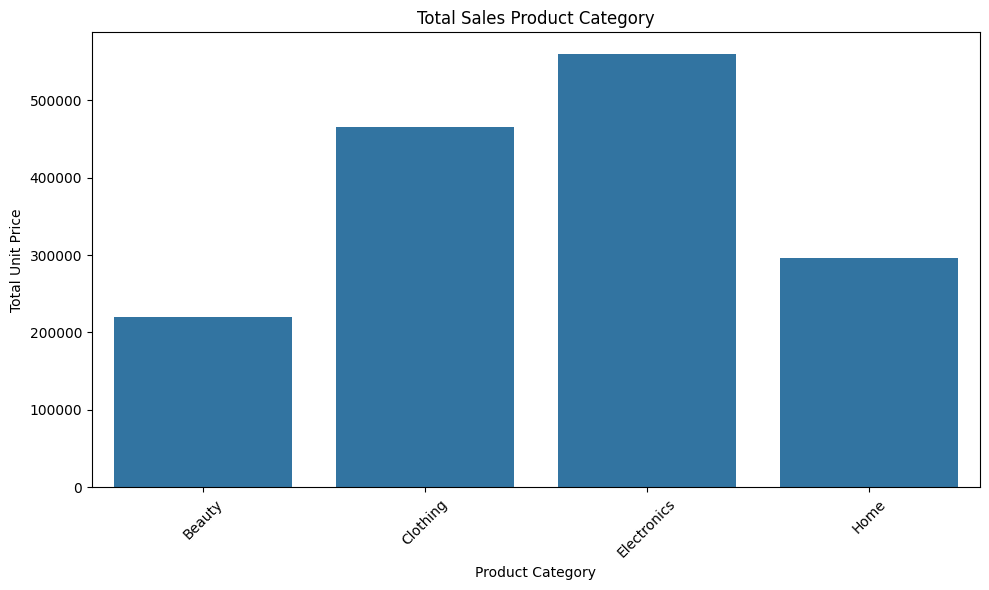

In [23]:
#PERFORMA SALES TIAP KATEGORI
plt.figure(figsize=(10, 6))
sns.barplot(
    data= performance,
    x='product_category',
    y='unit_price',
)
plt.title('Total Sales Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Unit Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

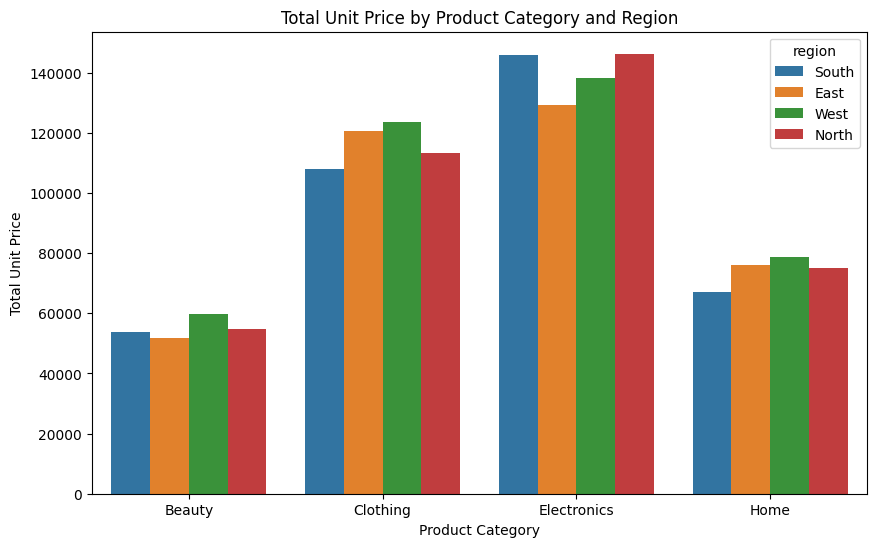

In [ ]:
## PERFORMA SALES TIAP REGION dari setiap KATEGORI
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x='product_category',
    y='unit_price',
    hue='region',
    estimator='sum',  # Seaborn defaults to mean, so specify 'sum'
    errorbar=None     # Optional: removes confidence interval bars
)

plt.title('Total Unit Price by Product Category and Region')
plt.xlabel('Product Category')
plt.ylabel('Total Unit Price')
plt.show()